In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn import set_config

In [2]:
set_config(display="diagram", transform_output="pandas")

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Naman-Agrawal19/csv_data/refs/heads/main/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
df.shape

(10000, 14)

In [6]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.loc[
    (df.isna().any(axis=1)),:
]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.loc[
    (df.duplicated(keep=False)), :
]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


## EDA


In [10]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df.drop(columns=columns_to_drop, inplace=True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df.rename(columns=lambda x: x.lower(), inplace=True)

In [13]:
x = df.drop(columns='exited')
y = df['exited']

In [14]:
df.dtypes

creditscore          int64
geography              str
gender                 str
age                  int64
tenure               int64
balance            float64
numofproducts        int64
hascrcard            int64
isactivemember       int64
estimatedsalary    float64
exited               int64
dtype: object

In [15]:
numerical_columns = pd.Series([i for i in x.columns if x[i].dtype in ['int64', 'float64']])
categorical_columns = pd.Series([i for i in x.columns if x[i].dtype in ['object', 'str', 'bool']])

In [16]:
categorical_columns

0    geography
1       gender
dtype: str

In [17]:
bool_cols = numerical_columns[numerical_columns.isin(['hascrcard', 'isactivemember'])].reset_index(drop=True)
bool_cols

0         hascrcard
1    isactivemember
dtype: str

In [18]:
ordinal_cols = numerical_columns[numerical_columns.isin(['tenure', 'numofproducts'])].reset_index(drop=True)

In [19]:
numerical_columns = numerical_columns[~numerical_columns.isin(bool_cols.values.tolist() + ordinal_cols.values.tolist())].reset_index(drop=True)
numerical_columns

0        creditscore
1                age
2            balance
3    estimatedsalary
dtype: str

In [20]:
from matplotlib.gridspec import GridSpec
import seaborn as sns

In [21]:
def plots_numerical_columns(df, column_name, bins, kde = True):
    plt.figure(figsize = (8, 6))

    grid = GridSpec(nrows = 2, ncols = 2)

    ax1 = plt.subplot(grid[0, :])
    ax2 = plt.subplot(grid[1, 0])

    sns.histplot(data = df, x = column_name, bins = bins, kde = kde, ax = ax1)
    ax1.set_title(column_name)
    sns.boxplot(data = df, x = column_name, ax = ax2)
    ax2.set_title(column_name)
    plt.tight_layout()
    plt.show()

In [22]:
col_bins = {
    column_name:bin_val for column_name, bin_val in zip(numerical_columns.values, [50, 15]+ ["auto"]*4)    
}
col_bins

{'creditscore': 50, 'age': 15, 'balance': 'auto', 'estimatedsalary': 'auto'}

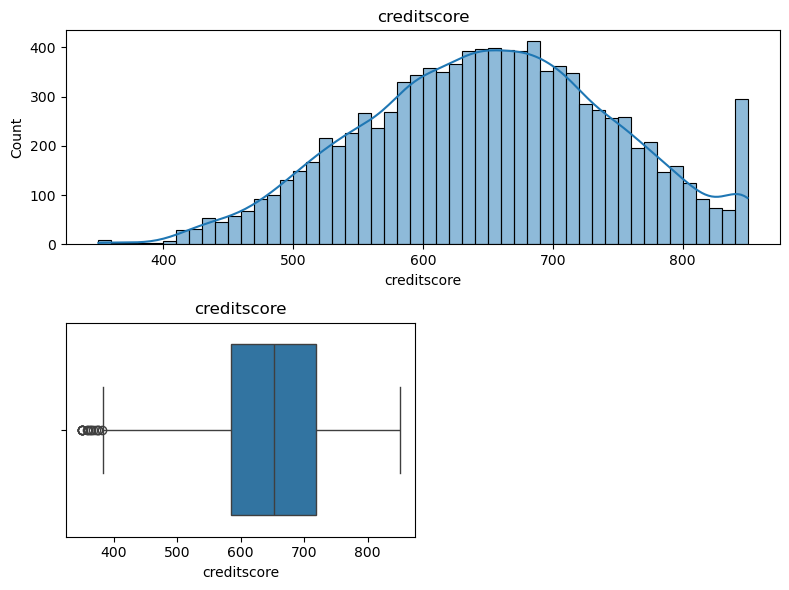

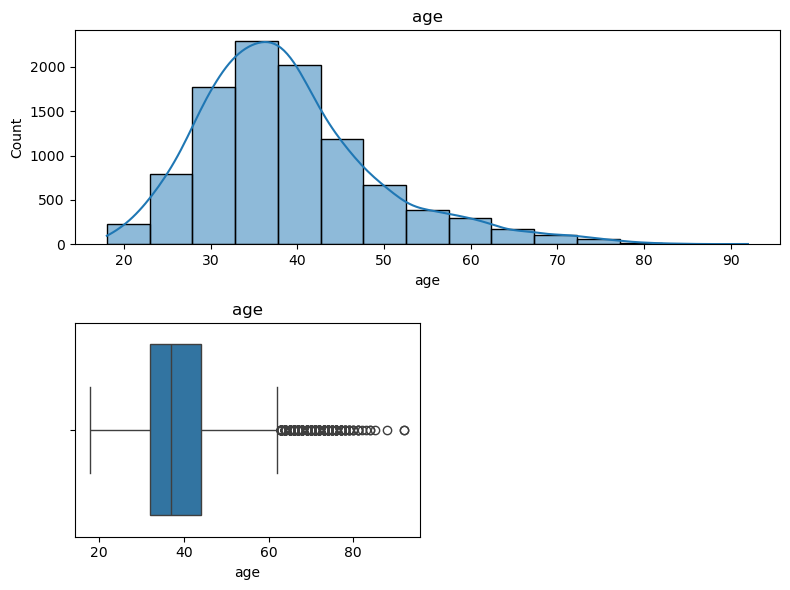

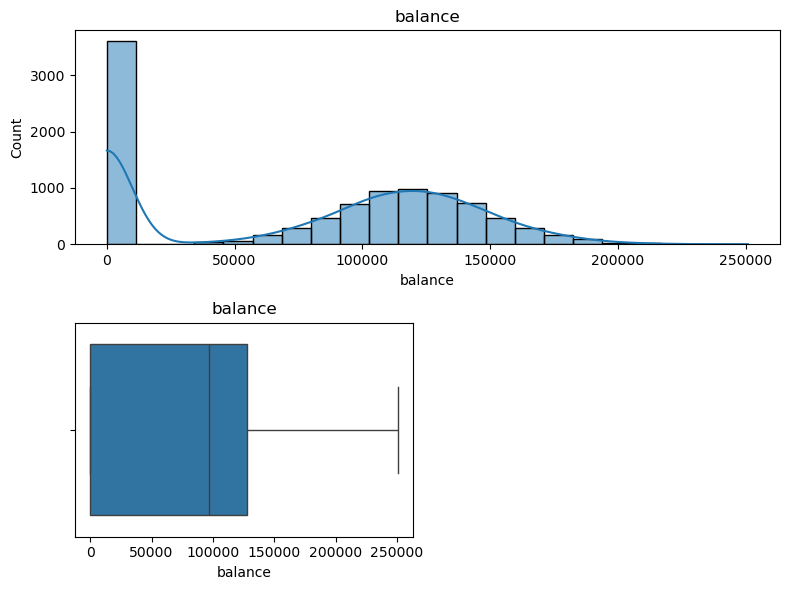

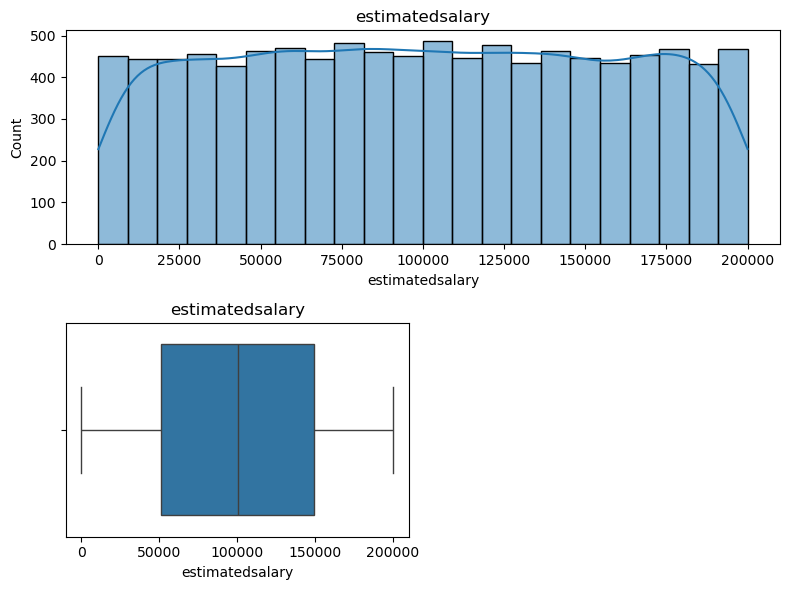

In [23]:
for cols in numerical_columns.values:
    plots_numerical_columns(x, cols, col_bins[cols])


In [24]:
x.loc[
    x.balance == 0, :
]

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary
0,619,France,Female,42,2,0.0,1,1,1,101348.88
3,699,France,Female,39,1,0.0,2,0,0,93826.63
6,822,France,Male,50,7,0.0,2,1,1,10062.80
11,497,Spain,Male,24,3,0.0,2,1,0,76390.01
12,476,France,Female,34,10,0.0,2,1,0,26260.98
...,...,...,...,...,...,...,...,...,...,...
9989,841,Spain,Male,28,4,0.0,2,1,1,179436.60
9992,726,Spain,Male,36,2,0.0,1,1,0,195192.40
9994,800,France,Female,29,2,0.0,2,0,0,167773.55
9995,771,France,Male,39,5,0.0,2,1,0,96270.64


In [25]:
# new col for 0 balance customers
x['iszerobal'] = x['balance'].apply(lambda x: 1 if x == 0 else 0)

In [26]:
x

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,iszerobal
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,1
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,1
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,0


In [27]:
def plots_categorical_columns(df, column_name):
    display(x[column_name].value_counts(normalize=True))
    sns.countplot(data = df, x = column_name)
    plt.title(column_name)
    plt.show()
    print("--"*50)

geography
France     0.5014
Germany    0.2509
Spain      0.2477
Name: proportion, dtype: float64

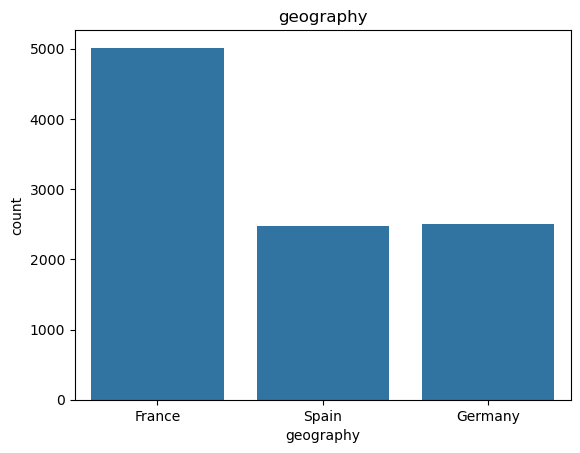

----------------------------------------------------------------------------------------------------


gender
Male      0.5457
Female    0.4543
Name: proportion, dtype: float64

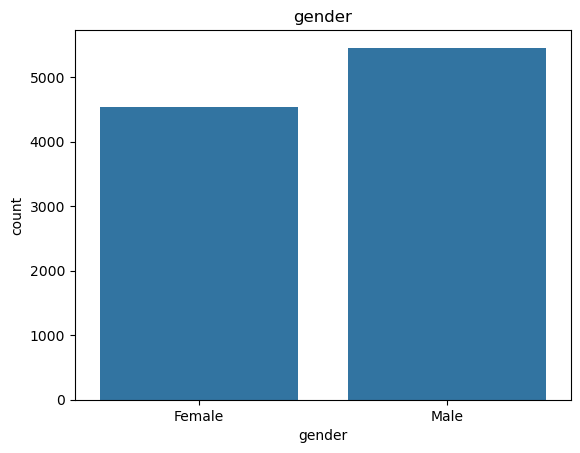

----------------------------------------------------------------------------------------------------


In [28]:
for cc in categorical_columns:
    plots_categorical_columns(x, cc)

In [29]:
y.value_counts(normalize=True)

exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [30]:
bool_cols[2] = 'iszerobal'

hascrcard
1    0.7055
0    0.2945
Name: proportion, dtype: float64

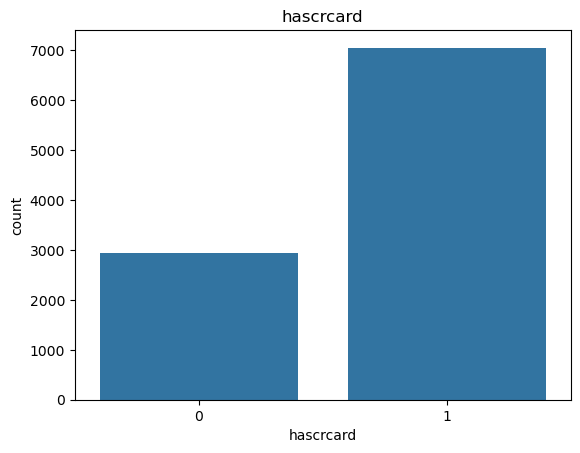

----------------------------------------------------------------------------------------------------


isactivemember
1    0.5151
0    0.4849
Name: proportion, dtype: float64

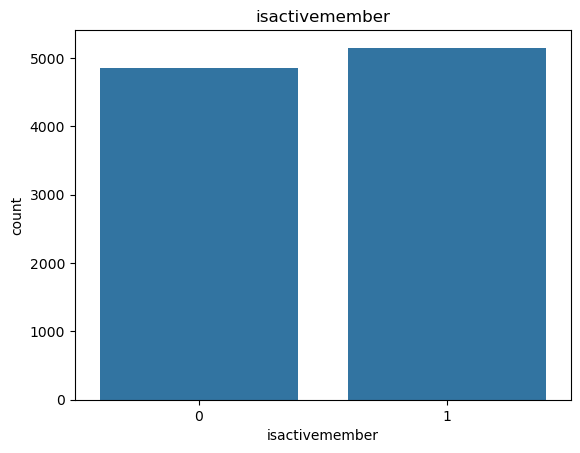

----------------------------------------------------------------------------------------------------


iszerobal
0    0.6383
1    0.3617
Name: proportion, dtype: float64

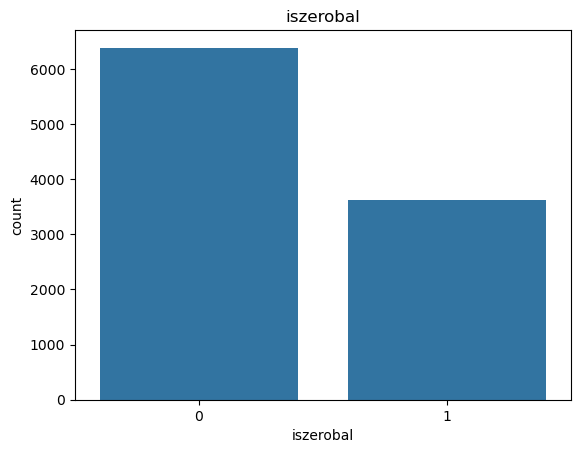

----------------------------------------------------------------------------------------------------


In [31]:
for cc in bool_cols:
    plots_categorical_columns(x, cc)

## FE and model training

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [34]:
x_train.shape, x_test.shape

((8000, 11), (2000, 11))

In [35]:
numerical_columns

0        creditscore
1                age
2            balance
3    estimatedsalary
dtype: str

In [36]:
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor = ColumnTransformer(transformers=[
    ("scaler", scaler, numerical_columns),
    ("encoder", encoder, categorical_columns)
    ], remainder='passthrough', verbose_feature_names_out=False)

In [37]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [38]:
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

In [39]:
x_train_transformed

,creditscore,age,balance,estimatedsalary,geography_France,geography_Germany,geography_Spain,gender_Female,gender_Male,tenure,numofproducts,hascrcard,isactivemember,iszerobal
9254,0.356500,-0.655786,-1.218471,1.367670,1.0,0.0,0.0,0.0,1.0,6,2,1,1,1
1561,-0.203898,0.294938,0.696838,1.661254,0.0,1.0,0.0,0.0,1.0,4,2,1,1,0
1670,-0.961472,-1.416365,0.618629,-0.252807,0.0,0.0,1.0,0.0,1.0,3,1,1,0,0
6087,-0.940717,-1.131148,0.953212,0.915393,1.0,0.0,0.0,1.0,0.0,9,1,1,0,0
6669,-1.397337,1.625953,1.057449,-1.059600,1.0,0.0,0.0,0.0,1.0,9,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,1.207474,1.435808,-0.102301,-0.539860,1.0,0.0,0.0,0.0,1.0,8,1,1,1,0
5191,0.314989,1.816097,-1.218471,-1.733882,1.0,0.0,0.0,1.0,0.0,1,1,1,1,1
5390,0.865009,-0.085351,-1.218471,-0.142765,1.0,0.0,0.0,1.0,0.0,1,3,0,0,1
860,0.159323,0.390011,1.827259,-0.050826,1.0,0.0,0.0,0.0,1.0,8,1,1,0,0


## model building

In [40]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

In [41]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
xgb = XGBClassifier(class_weight='balanced', random_state=42, device='cuda')
lgb = LGBMClassifier(class_weight='balanced', random_state=42)

In [42]:
model1 = VotingClassifier(estimators=[
    ('rf', rf),
    ('xgb', xgb),
    ('lgb', lgb)
], voting='soft')
model1

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [43]:
model1.fit(x_train_transformed, y_train)

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:41] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:41] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:41] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1644, number of negative: 6356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [44]:
y_pred = model1.predict(x_test_transformed)

In [45]:
model1.predict_proba(x_test_transformed.iloc[0:5, :])

array([[0.966295  , 0.033705  ],
       [0.9676706 , 0.0323294 ],
       [0.84474504, 0.15525495],
       [0.91303395, 0.08696605],
       [0.85998641, 0.14001359]])

In [46]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1607
           1       0.67      0.56      0.61       393

    accuracy                           0.86      2000
   macro avg       0.79      0.75      0.77      2000
weighted avg       0.85      0.86      0.86      2000



## HP

In [47]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [48]:
model1.estimators_

[RandomForestClassifier(class_weight='balanced', random_state=42),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               class_weight='balanced', colsample_bylevel=None,
               colsample_bynode=None, colsample_bytree=None, device='cuda',
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None, ...),
 LGBMClassifier(class_weight='balanced', random_state=42)]

In [49]:
def objective(trial: optuna.Trial):
    params_dict = {
        "rf__n_estimators": trial.suggest_int("rf__n_estimators", 50, 200),
        "rf__max_depth": trial.suggest_int("rf__max_depth", 5, 12),
        "rf__max_samples": trial.suggest_float("rf__max_samples", 0.5, 1.0),
        "xgb__learning_rate": trial.suggest_float("xgb__learning_rate", 0.01, 0.5),
        "xgb__max_depth": trial.suggest_int("xgb__max_depth", 5, 15),
        "xgb__n_estimators": trial.suggest_int("xgb__n_estimators", 30, 200),
        "xgb__subsample": trial.suggest_float("xgb__subsample", 0.5, 1.0),
        "xgb__colsample_bynode": trial.suggest_float("xgb__colsample_bynode", 0.5, 1.0),
        "xgb__reg_lambda": trial.suggest_float("xgb__reg_lambda", 0.1, 10.0),
        "lgbm__max_depth": trial.suggest_int("lgbm__max_depth", 5, 15),
        "lgbm__n_estimators": trial.suggest_int("lgbm__n_estimators", 30, 200),
        "lgbm__learning_rate": trial.suggest_float("lgbm__learning_rate", 0.01, 0.5),
        "lgbm__subsample": trial.suggest_float("lgbm__subsample", 0.5, 1.0),
        "lgbm__reg_lambda": trial.suggest_float("lgbm__reg_lambda", 0.1, 10.0)
    }

    # define models
    rf = RandomForestClassifier(class_weight='balanced', random_state=42)
    xgb = XGBClassifier(class_weight='balanced', random_state=42)
    lgbm = LGBMClassifier(class_weight='balanced', random_state=42)

    # build a voting classifier
    model = VotingClassifier(estimators=[
        ('rf', rf), 
        ('xgb', xgb), 
        ('lgbm', lgbm)
        ], voting='soft')


    model.set_params(**params_dict)

    scores = cross_val_score(model, x_train_transformed, y_train, scoring='f1', cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

    mean_f1 = np.mean(scores)
    return mean_f1

In [50]:
# define my study
study = optuna.create_study(direction="maximize")
study.optimize(func=objective,n_trials=20,show_progress_bar=True)

[I 2026-05-20 01:26:44,697] A new study created in memory with name: no-name-8a946143-a0a0-42f9-b8fb-85ef1f003144


  0%|          | 0/20 [00:00<?, ?it/s]

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:46] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:47] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:48] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:49] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000415 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:49] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:26:50,175] Trial 0 finished with value: 0.6114293547050492 and parameters: {'rf__n_estimators': 153, 'rf__max_depth': 9, 'rf__max_samples': 0.6781786720609063, 'xgb__learning_rate': 0.27415190417535495, 'xgb__max_depth': 7, 'xgb__n_estimators': 88, 'xgb__subsample': 0.5345229634057184, 'xgb__colsample_bynode': 0.51197770468346, 'xgb__reg_lambda': 3.954061627981682, 'lgbm__max_depth': 9, 'lgbm__n_estimators': 30, 'lgbm__learning

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:50] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:51] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000551 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:52] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:53] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000352 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:54] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:26:56,541] Trial 1 finished with value: 0.607394537822797 and parameters: {'rf__n_estimators': 149, 'rf__max_depth': 5, 'rf__max_samples': 0.5245844124857736, 'xgb__learning_rate': 0.275095210297655, 'xgb__max_depth': 8, 'xgb__n_estimators': 83, 'xgb__subsample': 0.897350126786211, 'xgb__colsample_bynode': 0.7659803087789732, 'xgb__reg_lambda': 1.2655277630915907, 'lgbm__max_depth': 15, 'lgbm__n_estimators': 103, 'lgbm__learnin

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:57] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:58] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000221 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:26:59] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000325 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:01] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:02] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[I 2026-05-20 01:27:02,427] Trial 2 finished with value: 0.6183972745319144 and parameters: {'rf__n_estimators': 184, 'rf__max_depth': 8, 'rf__max_samples': 0.5252556493565839, 'xgb__learning_rate': 0.1956663821962614, 'xgb__max_depth': 7, 'xgb__n_estimators': 134, 'xgb__subsample': 0.916112879469

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:03] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:07] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:09] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000484 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:11] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:27:12,716] Trial 3 finished with value: 0.6020229843435575 and parameters: {'rf__n_estimators': 185, 'rf__max_depth': 11, 'rf__max_samples': 0.7239852446802353, 'xgb__learning_rate': 0.2106427980375751, 'xgb__max_depth': 9, 'xgb__n_estimators': 160, 'xgb__subsample': 0.9423801388195405, 'xgb__colsample_bynode': 0.9653196709634573, 'xgb__reg_lambda': 6.085166872133566, 'lgbm__max_depth': 11, 'lgbm__n_estimators': 131, 'lgbm__lea

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:13] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:13] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:14] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:15] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:16] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:27:16,234] Trial 4 finished with value: 0.608262830281392 and parameters: {'rf__n_estimators': 73, 'rf__max_depth': 9, 'rf__max_samples': 0.8553412972900711, 'xgb__learning_rate': 0.4733411226064182, 'xgb__max_depth': 9, 'xgb__n_estimators': 47, 'xgb__subsample': 0.9838310217606597, 'xgb__colsample_bynode': 0.8433154134107907, 'xgb__reg_lambda': 2.3362165319009396, 'lgbm__max_depth': 8, 'lgbm__n_estimators': 106, 'lgbm__learnin

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:16] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:17] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:19] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:20] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:21] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:22] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:22] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:23] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:24] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:24] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[I 2026-05-20 01:27:25,173] Trial 6 finished with value: 0.6096512835045675 and parameters: {'rf__n_estimators': 76, 'rf__max_depth': 5, 'rf__max_samples': 0.8801467074031076, 'xgb__learning_rate': 0.23120982529032527, 'xgb__max_depth': 9, 'xgb__n_estimators': 120, 'xgb__subsample': 0.9505504838526466, 'xgb__colsample_bynode': 0.63643738724364, 'xgb__reg_lambda': 1.71757

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:25] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:27] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:29] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:30] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:27:31,374] Trial 7 finished with value: 0.6143283734484375 and parameters: {'rf__n_estimators': 118, 'rf__max_depth': 12, 'rf__max_samples': 0.935450715625523, 'xgb__learning_rate': 0.39818787584669946, 'xgb__max_depth': 10, 'xgb__n_estimators': 140, 'xgb__subsample': 0.5211796903697962, 'xgb__colsample_bynode': 0.9196160280432011, 'xgb__reg_lambda': 8.811961166933648, 'lgbm__max_depth': 15, 'lgbm__n_estimators': 39, 'lgbm__lea

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:32] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:33] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:34] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:35] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:36] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:27:36,335] Trial 8 finished with value: 0.618182414004578 and parameters: {'rf__n_estimators': 164, 'rf__max_depth': 7, 'rf__max_samples': 0.8561551949515056, 'xgb__learning_rate': 0.374192350433375, 'xgb__max_depth': 10, 'xgb__n_estimators': 30, 'xgb__subsample': 0.584406589171807, 'xgb__colsample_bynode': 0.8540394335050991, 'xgb__reg_lambda': 2.41595959439353, 'lgbm__max_depth': 10, 'lgbm__n_estimators': 74, 'lgbm__learning_

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:36] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:38] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:39] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:40] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:41] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:42] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:44] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:45] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:46] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:48] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:50] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:51] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:52] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:54] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000338 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:55] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:56] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:57] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:58] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:27:59] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:00] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:01] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:02] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:03] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:04] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:06] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:07] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000236 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:08] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:09] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:10] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:11] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:12] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:13] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:14] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:15] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:28:15,820] Trial 15 finished with value: 0.6282326961671169 and parameters: {'rf__n_estimators': 171, 'rf__max_depth': 6, 'rf__max_samples': 0.7732102764619005, 'xgb__learning_rate': 0.12598743435604465, 'xgb__max_depth': 5, 'xgb__n_estimators': 59, 'xgb__subsample': 0.8319616119410751, 'xgb__colsample_bynode': 0.5943132720875514, 'xgb__reg_lambda': 5.419284431273932, 'lgbm__max_depth': 12, 'lgbm__n_estimators': 63, 'lgbm__lear

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:16] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:17] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:18] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:19] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:20] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:28:20,714] Trial 16 finished with value: 0.6226509824685784 and parameters: {'rf__n_estimators': 174, 'rf__max_depth': 6, 'rf__max_samples': 0.7818188171659382, 'xgb__learning_rate': 0.13352759432891237, 'xgb__max_depth': 5, 'xgb__n_estimators': 58, 'xgb__subsample': 0.8342469393346797, 'xgb__colsample_bynode': 0.579544508221076, 'xgb__reg_lambda': 3.706183085363588, 'lgbm__max_depth': 13, 'lgbm__n_estimators': 130, 'lgbm__lear

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:20] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:21] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:22] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:22] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:23] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:28:23,852] Trial 17 finished with value: 0.6156897925732705 and parameters: {'rf__n_estimators': 52, 'rf__max_depth': 6, 'rf__max_samples': 0.7986561207147895, 'xgb__learning_rate': 0.15234979583940939, 'xgb__max_depth': 13, 'xgb__n_estimators': 56, 'xgb__subsample': 0.8536742253741919, 'xgb__colsample_bynode': 0.5928636650171595, 'xgb__reg_lambda': 0.15584689253236572, 'lgbm__max_depth': 12, 'lgbm__n_estimators': 57, 'lgbm__le

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:24] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:25] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:26] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:27] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:28:28,504] Trial 18 finished with value: 0.6248243530675086 and parameters: {'rf__n_estimators': 139, 'rf__max_depth': 10, 'rf__max_samples': 0.7302878517229248, 'xgb__learning_rate': 0.1625652294122621, 'xgb__max_depth': 7, 'xgb__n_estimators': 33, 'xgb__subsample': 0.6357819660620052, 'xgb__colsample_bynode': 0.7910967499644358, 'xgb__reg_lambda': 5.530494316200773, 'lgbm__max_depth': 13, 'lgbm__n_estimators': 94, 'lgbm__lear

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:29] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1316, number of negative: 5084
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:30] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:31] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:32] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:33] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1315, number of negative: 5085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[I 2026-05-20 01:28:33,612] Trial 19 finished with value: 0.614291798345362 and parameters: {'rf__n_estimators': 135, 'rf__max_depth': 10, 'rf__max_samples': 0.9889146920927365, 'xgb__learning_rate': 0.30043562824703984, 'xgb__max_depth': 7, 'xgb__n_estimators': 39, 'xgb__subsample': 0.6271704678263317, 'xgb__colsample_bynode': 0.8697931325761653, 'xgb__reg_lambda': 5.074082682682508, 'lgbm__max_depth': 13, 'lgbm__n_estimators': 97, 'lgbm__lear

In [51]:
study.best_params

{'rf__n_estimators': 171,
 'rf__max_depth': 6,
 'rf__max_samples': 0.7732102764619005,
 'xgb__learning_rate': 0.12598743435604465,
 'xgb__max_depth': 5,
 'xgb__n_estimators': 59,
 'xgb__subsample': 0.8319616119410751,
 'xgb__colsample_bynode': 0.5943132720875514,
 'xgb__reg_lambda': 5.419284431273932,
 'lgbm__max_depth': 12,
 'lgbm__n_estimators': 63,
 'lgbm__learning_rate': 0.08624872833171354,
 'lgbm__subsample': 0.6159058619374224,
 'lgbm__reg_lambda': 8.154639985281175}

In [52]:
study.best_value

0.6282326961671169

In [53]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
xgb = XGBClassifier(class_weight='balanced', random_state=42)
lgbm = LGBMClassifier(class_weight='balanced', random_state=42)

model = VotingClassifier(estimators=[
    ('rf', rf),
    ('xgb', xgb),
    ('lgbm', lgbm),
], voting='soft')

model.set_params(**study.best_params)

model

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",171
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [54]:
model.fit(x_train_transformed, y_train)

[LightGBM] [Info] Number of positive: 1644, number of negative: 6356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [01:28:35] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125036904/work/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",171
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [55]:
y_pred = model.predict(x_test_transformed)

In [56]:
model.predict_proba(x_test_transformed.iloc[0:5, :])

array([[0.84705846, 0.15294155],
       [0.8674268 , 0.1325732 ],
       [0.70474289, 0.29525712],
       [0.62442448, 0.37557553],
       [0.76893551, 0.2310645 ]])

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1607
           1       0.62      0.68      0.65       393

    accuracy                           0.86      2000
   macro avg       0.77      0.79      0.78      2000
weighted avg       0.86      0.86      0.86      2000



## Shap

In [58]:
try:
    explainer = shap.TreeExplainer(model, data=x_train_transformed, model_output='probability')
except Exception as e:
    print(f"Error occurred while creating TreeExplainer: {e}")

Error occurred while creating TreeExplainer: Model type not yet supported by TreeExplainer: <class 'sklearn.ensemble._voting.VotingClassifier'>


In [59]:
model

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",171
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [60]:
model.predict_proba(x_test_transformed.iloc[0:5])[:,1]

array([0.15294155, 0.1325732 , 0.29525712, 0.37557553, 0.2310645 ])

In [61]:
def prediction_fn(x):
    predictions = model.predict_proba(x)[:,1]
    return predictions

In [62]:
explainer = shap.Explainer(
    prediction_fn,
    x_train_transformed
)

In [63]:
shap_values = explainer(x_test_transformed.iloc[[1],:])
shap_values

.values =
array([[ 0.00396942,  0.06372809, -0.03650264, -0.00322945, -0.00216142,
        -0.00917968,  0.00064635, -0.02334668, -0.0062541 ,  0.00886498,
        -0.12215269, -0.00063796, -0.03837552, -0.01437123]])

.base_values =
array([0.31157573])

.data =
array([[-0.29729735,  0.3900109 , -1.21847056,  0.79888291,  1.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  1.        ,
         2.        ,  1.        ,  1.        ,  1.        ]])

In [64]:
shap_values.shape

(1, 14)

In [65]:
model.predict_proba(x_test_transformed.iloc[[1], :])[:,1]

array([0.1325732])

In [66]:
shap_values.values[0].sum()+shap_values.base_values[0]

np.float64(0.13257319864805708)

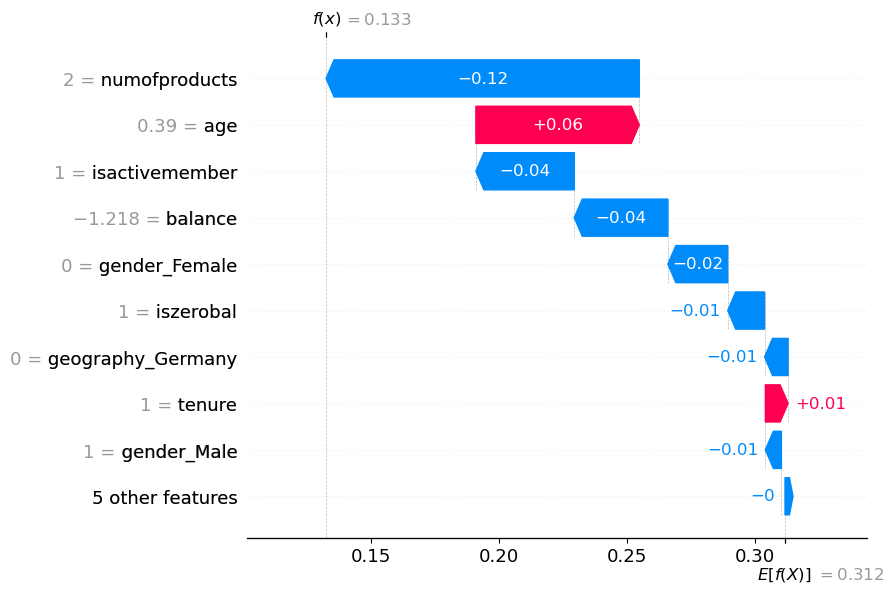

In [67]:
shap.plots.waterfall(shap_values[0])

In [68]:
shap_sample = explainer(x_test_transformed)

PermutationExplainer explainer: 2001it [28:12,  1.18it/s]                          


In [69]:
shap_sample.shape

(2000, 14)

## Global plots

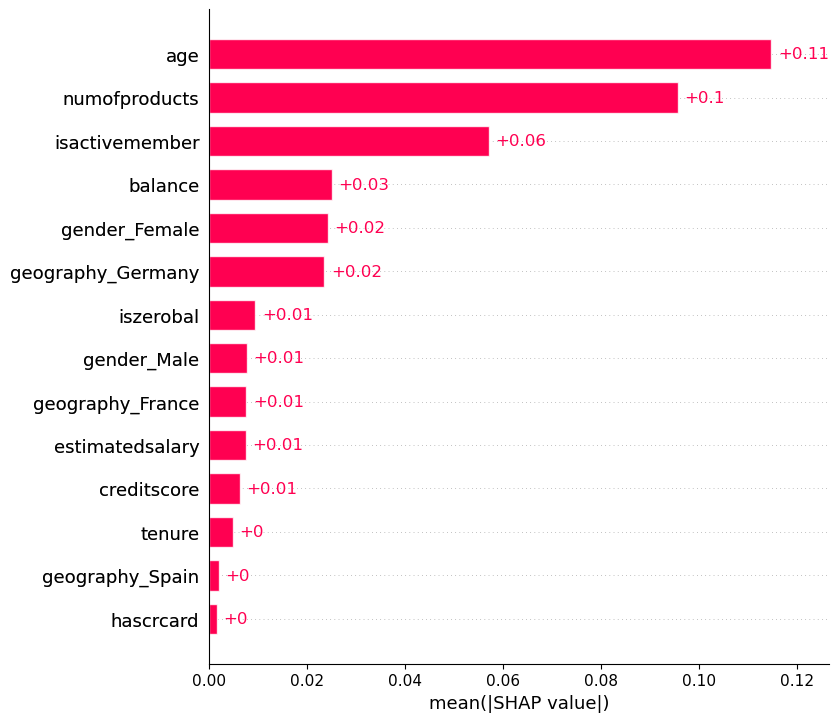

In [70]:
shap.plots.bar(shap_sample, max_display=15)

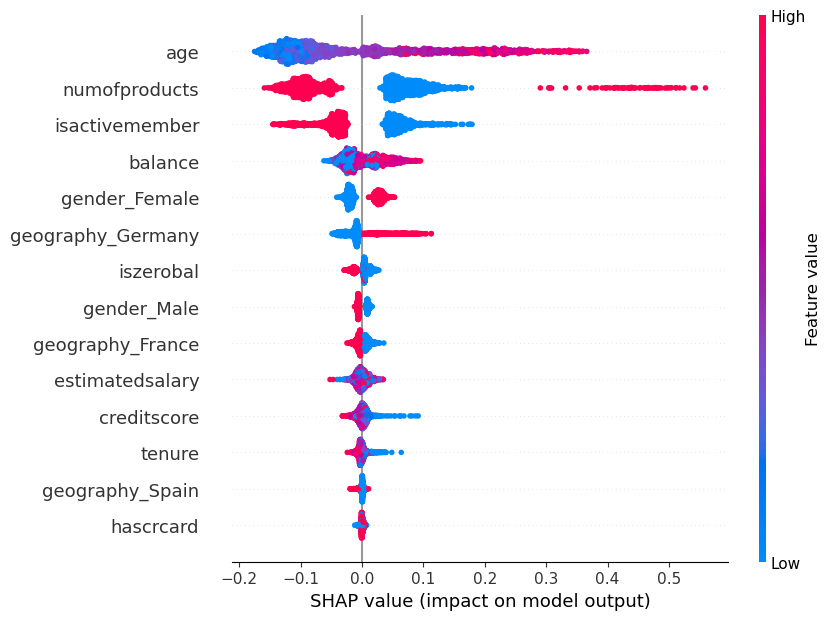

In [71]:
# summary plot
shap.plots.beeswarm(shap_sample, max_display=15)

In [72]:
x_test_transformed[['geography_Germany']].value_counts()

geography_Germany
0.0                  1502
1.0                   498
Name: count, dtype: int64

<Axes: title={'center': 'Age'}>

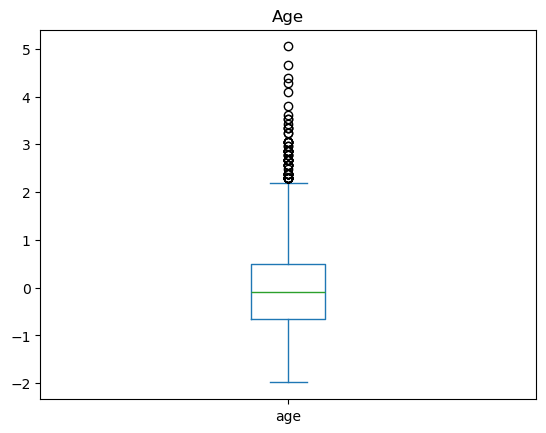

In [73]:
x_test_transformed[['age']].plot(kind='box', title='Age')

<Axes: title={'center': 'Num of Products'}>

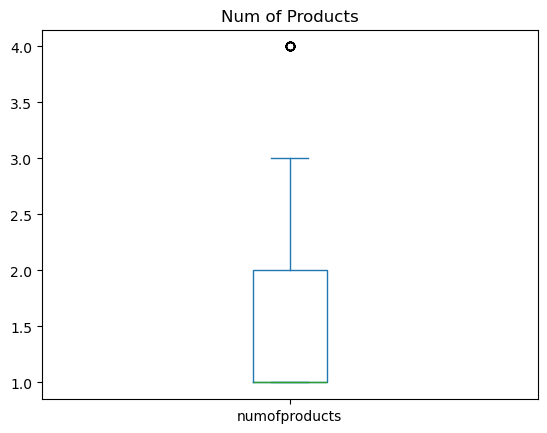

In [74]:
x_test_transformed.numofproducts.plot(kind='box', title='Num of Products')

In [75]:
x_test_transformed[x_test['numofproducts']>3]

,creditscore,age,balance,estimatedsalary,geography_France,geography_Germany,geography_Spain,gender_Female,gender_Male,tenure,numofproducts,hascrcard,isactivemember,iszerobal
4516,-1.604891,-0.655786,0.567351,-1.581027,0.0,1.0,0.0,1.0,0.0,8,4,1,1,0
7457,0.138567,0.390011,0.643964,-1.126503,0.0,1.0,0.0,1.0,0.0,2,4,1,0,0
4822,0.968786,-0.655786,-1.218471,1.378308,1.0,0.0,0.0,1.0,0.0,2,4,0,1,1
9411,0.387633,0.104794,0.032301,0.327357,0.0,1.0,0.0,1.0,0.0,4,4,1,0,0
2124,0.543299,-0.655786,0.827496,1.461061,1.0,0.0,0.0,0.0,1.0,7,4,0,0,0
4511,-0.183142,0.580156,-1.218471,0.010575,1.0,0.0,0.0,1.0,0.0,2,4,1,0,1
8683,0.470655,0.960446,1.907488,0.532941,1.0,0.0,0.0,1.0,0.0,7,4,0,1,0
2614,-1.096383,1.816097,0.486032,0.494661,0.0,1.0,0.0,1.0,0.0,3,4,1,0,0
1254,-0.245409,0.675228,-0.468029,-1.202447,1.0,0.0,0.0,1.0,0.0,1,4,1,0,0
1488,-0.577496,-0.845931,0.724397,-1.017286,0.0,0.0,1.0,0.0,1.0,6,4,1,0,0


In [76]:
shap_values2 = explainer(x_test_transformed[x_test['numofproducts']>3])

PermutationExplainer explainer: 16it [00:13,  3.34s/it]                        


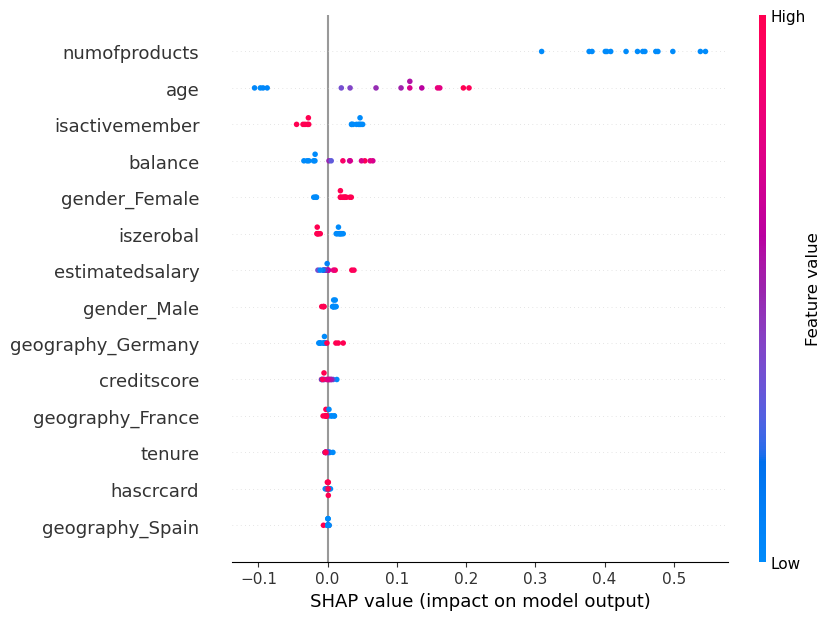

In [77]:
shap.plots.beeswarm(shap_values2, max_display=15)

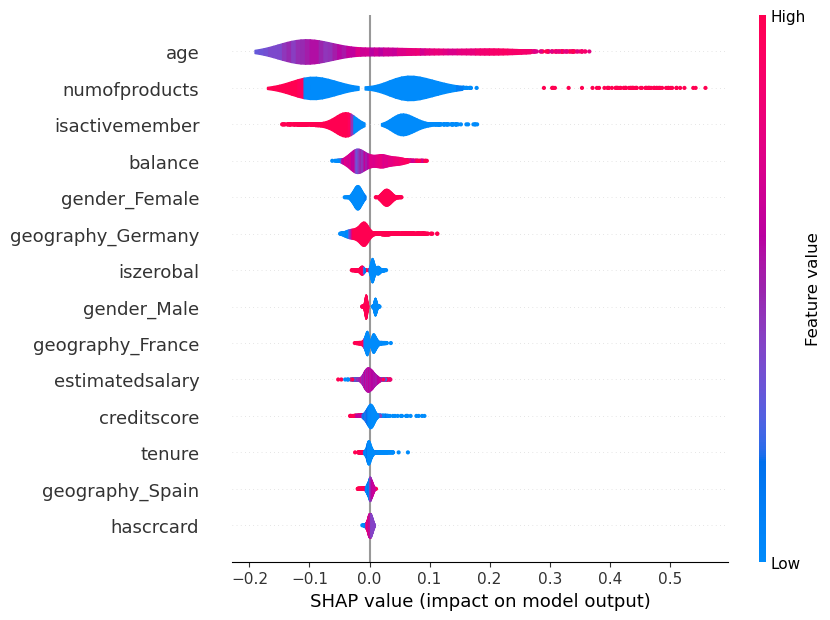

In [78]:
shap.plots.violin(shap_sample, max_display=15)

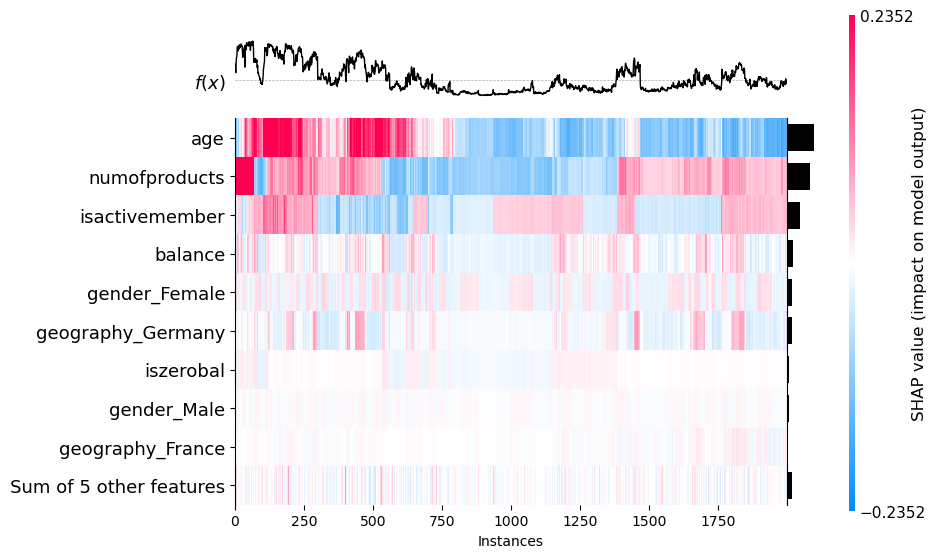

<Axes: xlabel='Instances'>

In [79]:
# heatmap plot
shap.plots.heatmap(shap_sample)

## local plot

In [80]:
test_case = x_test_transformed[y_test == 1].sample(1)

In [81]:
x_test.loc[test_case.index[0],:]

creditscore             564
geography            France
gender               Female
age                      53
tenure                    2
balance            45472.28
numofproducts             1
hascrcard                 1
isactivemember            1
estimatedsalary    41055.71
iszerobal                 0
Name: 8122, dtype: object

In [82]:
shap_testcase = explainer(test_case)
shap_testcase[0]

.values =
array([ 0.00033727,  0.26207912,  0.01495392, -0.01075329, -0.00412317,
       -0.01377619,  0.00436187,  0.02883231,  0.00860787,  0.00606483,
        0.10052398, -0.00167268, -0.08858487,  0.00477149])

.base_values =
np.float64(0.3115757293010432)

.data =
array([-0.90958348,  1.34073526, -0.49041436, -1.03234363,  1.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  2.        ,
        1.        ,  1.        ,  1.        ,  0.        ])

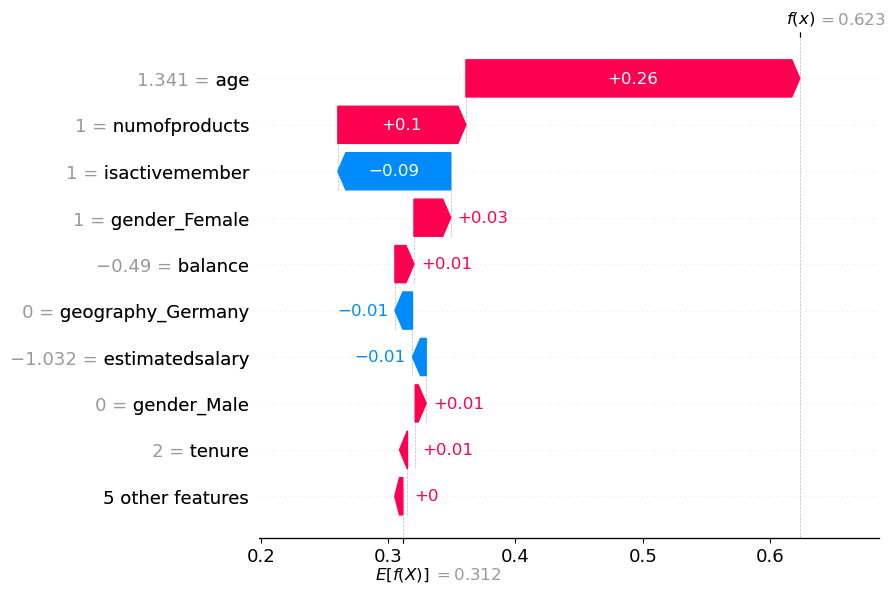

In [83]:
shap.plots.waterfall(shap_testcase[0])

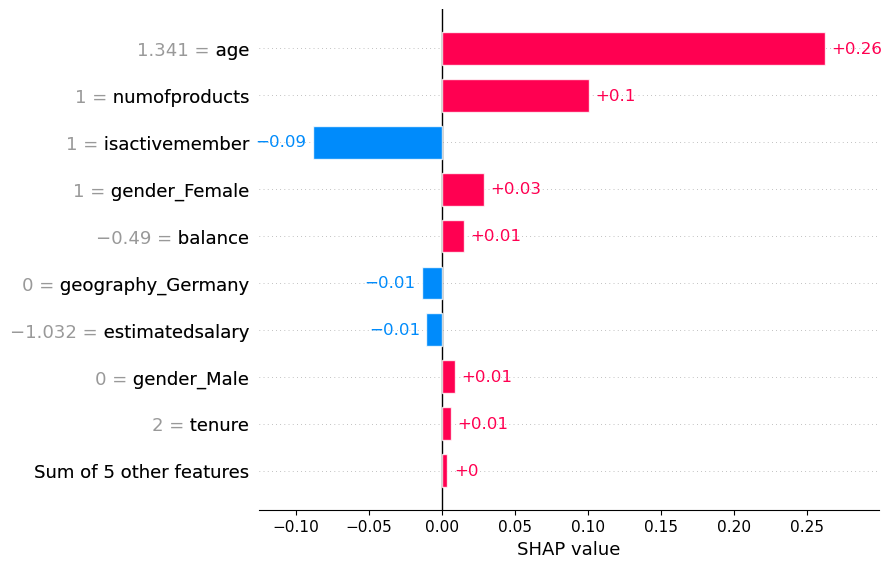

In [84]:
shap.plots.bar(shap_testcase[0])

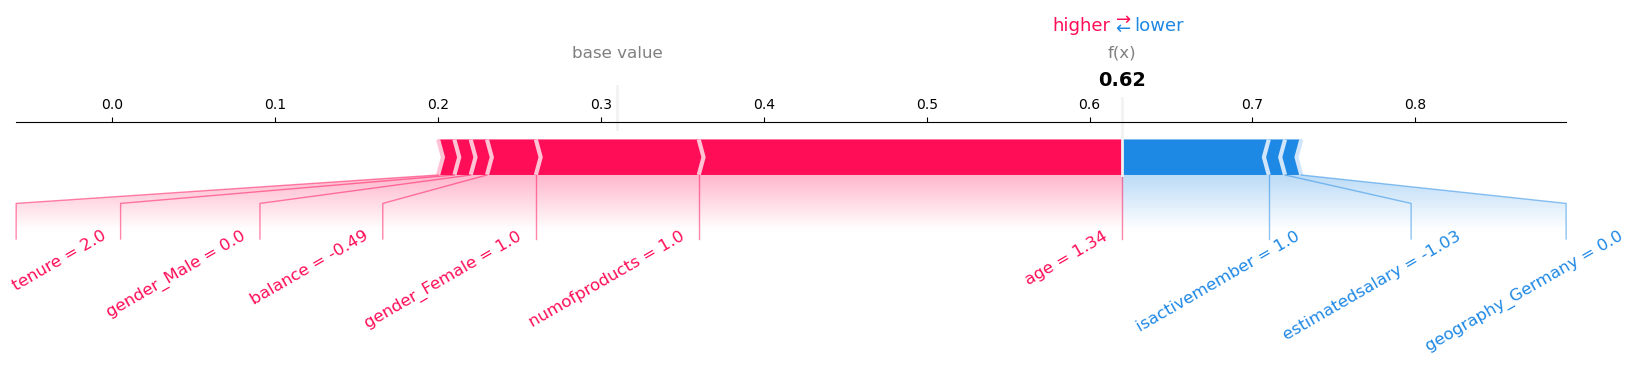

In [85]:
shap.plots.force(base_value = shap_testcase[0].base_values.round(2), shap_values=shap_testcase[0].values.round(2), features=shap_testcase[0].data.round(2), feature_names=shap_testcase.feature_names, matplotlib=True, text_rotation=30)

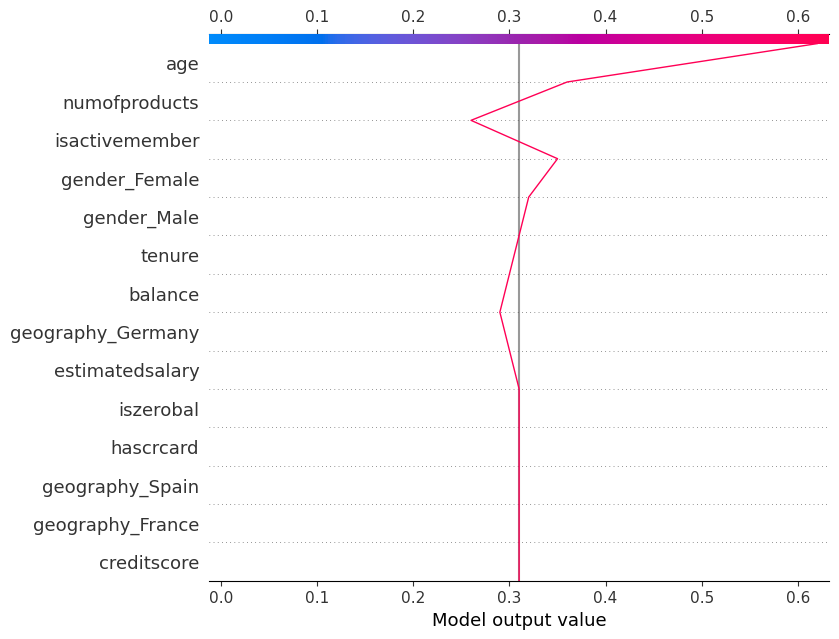

In [86]:
#decision plot
shap.plots.decision(base_value = shap_testcase[0].base_values.round(2), shap_values=shap_testcase[0].values.round(2), feature_names=shap_testcase.feature_names)

## Batch data plots

In [87]:
# sample of test data
sample_test_data = x_test_transformed.sample(3)
shap_sample_data = explainer(sample_test_data)

In [88]:
shap_sample_data

.values =
array([[-2.33448325e-03, -9.11541722e-02, -2.55145481e-02,
         5.09682074e-03, -4.95983998e-03, -8.35642008e-03,
         1.69746469e-05, -1.90955667e-02, -7.05999570e-03,
        -3.56318785e-03, -1.03635498e-01,  1.14833853e-03,
         3.89731455e-02, -1.16904855e-02],
       [-7.64063352e-03, -8.35684400e-02,  2.16000407e-02,
         8.01602435e-04,  5.08605057e-03,  2.18510369e-02,
        -2.90668109e-04, -2.17285702e-02, -6.22597784e-03,
        -1.70737475e-03, -8.35292601e-02,  1.59153739e-03,
        -3.75812560e-02,  1.07317155e-02],
       [-3.97150563e-03, -9.49795114e-02, -1.70482334e-02,
        -1.38176861e-02,  1.10353596e-02, -3.78731616e-02,
        -5.55559868e-03, -2.26101123e-02, -6.20640557e-03,
         1.21254625e-03,  4.18757094e-02, -8.46279172e-03,
         6.62762480e-02,  3.80516248e-03]])

.base_values =
array([0.31157573, 0.31157573, 0.31157573])

.data =
array([[-6.72087807e-03, -2.75496152e-01, -1.21847056e+00,
        -1.50452039e+00,

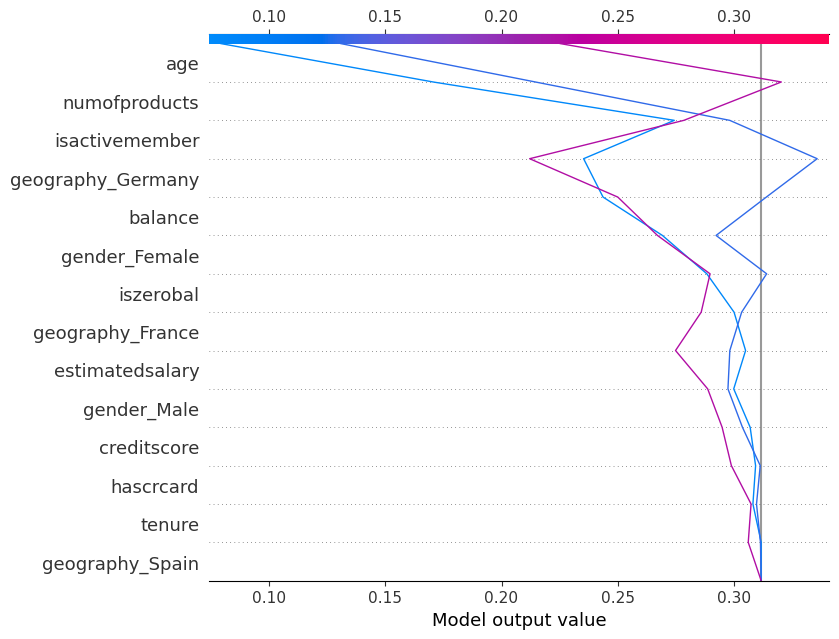

In [89]:
shap.plots.decision(shap_values = shap_sample_data.values, base_value=shap_sample_data.base_values[0], feature_names=shap_sample_data.feature_names)

## lime

In [90]:
from lime.lime_tabular import LimeTabularExplainer

In [91]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['creditscore', 'age', 'balance', 'estimatedsalary',
       'geography_France', 'geography_Germany', 'geography_Spain',
       'gender_Female', 'gender_Male', 'tenure', 'numofproducts',
       'hascrcard', 'isactivemember', 'iszerobal'], dtype=object)

In [92]:
test_case_lime = test_case.values.flatten()
test_case_lime

array([-0.90958348,  1.34073526, -0.49041436, -1.03234363,  1.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  2.        ,
        1.        ,  1.        ,  1.        ,  0.        ])

In [93]:
# list of index numbers of categorical features in data
categorical_features = [4, 5, 6, 7, 8, 11, 12, 13]

In [94]:
# create the explainer

lime_explainer = LimeTabularExplainer(
    training_data=x_train_transformed.values,
    mode="classification",
    feature_names=feature_names,
    categorical_features=categorical_features
)

In [95]:
lime_explanation = lime_explainer.explain_instance(data_row=test_case_lime,
                                                   predict_fn=model.predict_proba)

/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/naman/miniforge3/envs/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [96]:
# view my explanations --> as a list
lime_explanation.as_list()

[('age > 0.49', 0.3349823564888618),
 ('isactivemember=1', -0.1314944078447502),
 ('numofproducts <= 1.00', 0.08048083807565372),
 ('geography_Germany=0', -0.055666995538208884),
 ('gender_Female=1', 0.0517342148341886),
 ('gender_Male=0', 0.01834261613078277),
 ('geography_France=1', -0.01744042783730335),
 ('creditscore <= -0.69', 0.011196330625337834),
 ('tenure <= 3.00', 0.010975629572193495),
 ('-1.22 < balance <= 0.33', -0.010843366049123082)]

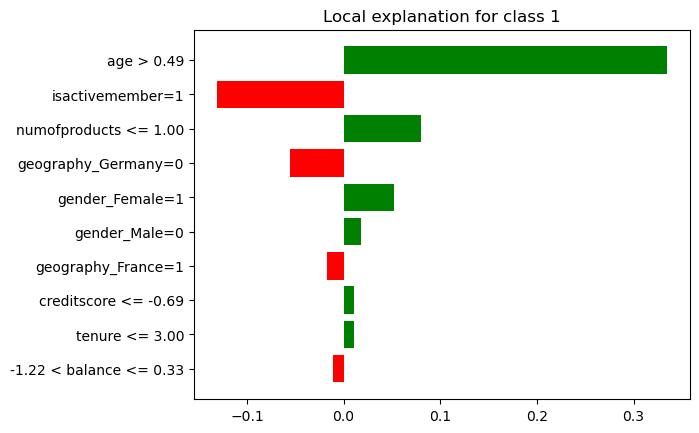

In [118]:
lime_explanation.as_pyplot_figure()
plt.show()